Load Dataset

In [3]:
import pandas as pd

df = pd.read_excel("Mall_Customers.xlsx")
df.head()

,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100)
0,1,M,19,High School,Married,15,39
1,2,M,21,Graduate,Single,15,81
2,3,F,20,Graduate,Married,16,6
3,4,F,23,High School,Unknown,16,77
4,5,F,31,Uneducated,Married,17,40


Verify it loaded correctly

In [4]:
df.info()
df.shape
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Education               200 non-null    object
 4   Marital Status          200 non-null    object
 5   Annual Income (k$)      200 non-null    int64 
 6   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(3)
memory usage: 11.1+ KB


,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100)
0,1,M,19,High School,Married,15,39
1,2,M,21,Graduate,Single,15,81
2,3,F,20,Graduate,Married,16,6
3,4,F,23,High School,Unknown,16,77
4,5,F,31,Uneducated,Married,17,40


Check Missing Values

In [5]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Education,0
Marital Status,0
Annual Income (k$),0
Spending Score (1-100),0


Exploratory Data Analysis (EDA)

In [6]:
df.head()

,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100)
0,1,M,19,High School,Married,15,39
1,2,M,21,Graduate,Single,15,81
2,3,F,20,Graduate,Married,16,6
3,4,F,23,High School,Unknown,16,77
4,5,F,31,Uneducated,Married,17,40


Import Libraries



In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

Gender Distribution

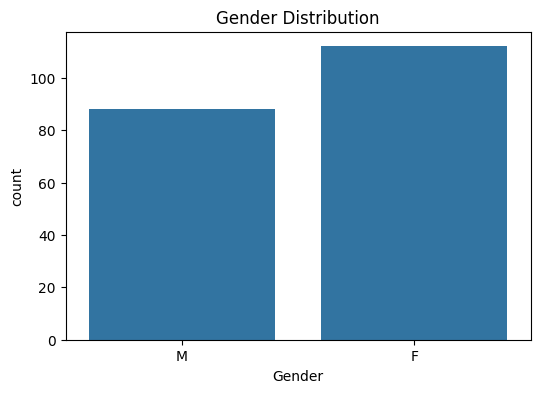

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df)
plt.title('Gender Distribution')
plt.show()

Age Distribution

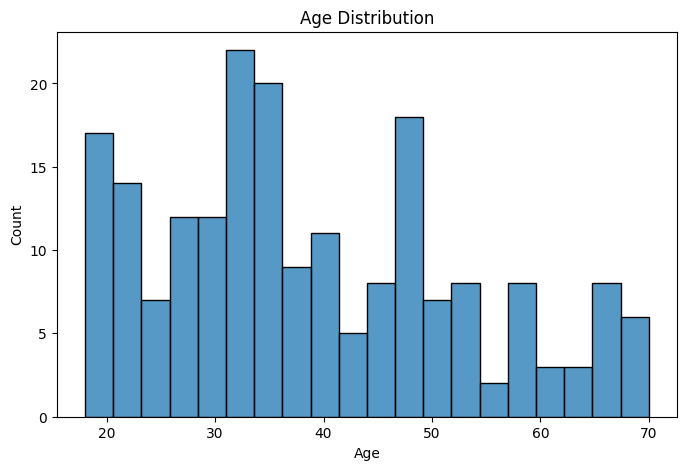

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20)
plt.title('Age Distribution')
plt.show()

Annual Income Distribution

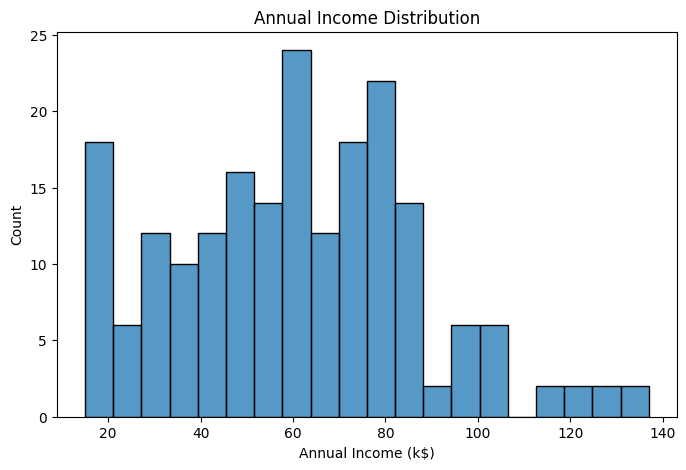

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['Annual Income (k$)'], bins=20)
plt.title('Annual Income Distribution')
plt.show()

Spending Score Distribution

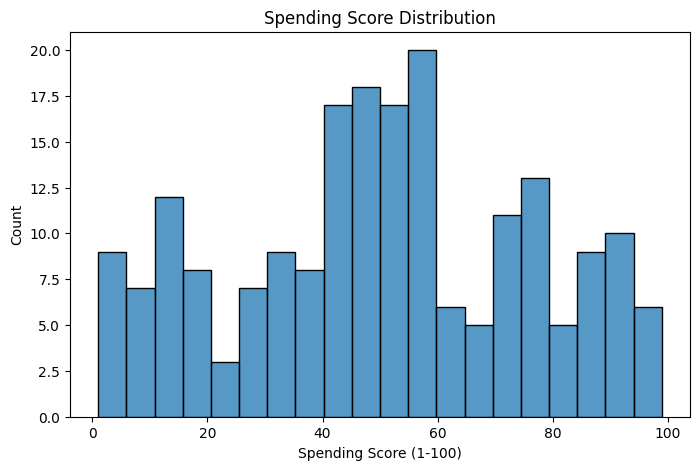

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['Spending Score (1-100)'], bins=20)
plt.title('Spending Score Distribution')
plt.show()

Correlation Heatmap

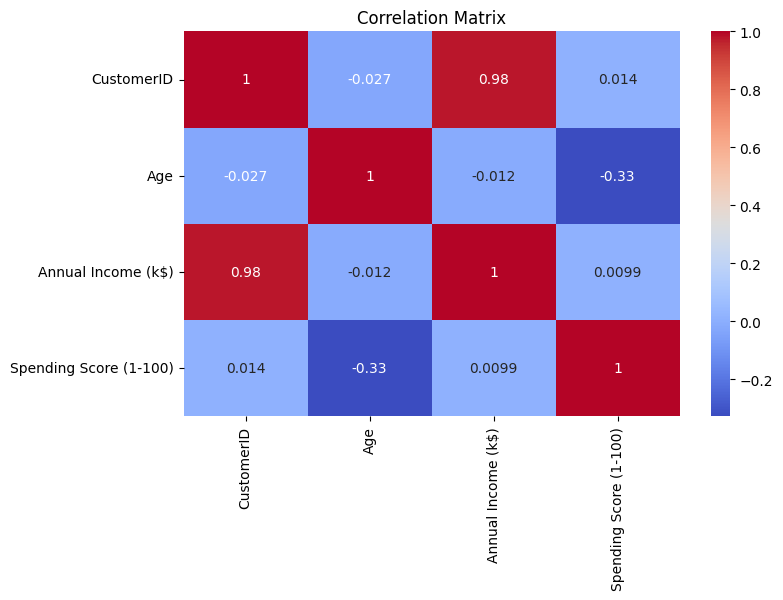

In [13]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,5))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title('Correlation Matrix')
plt.show()

Select Features

In [14]:
X = df[['Annual Income (k$)',
        'Spending Score (1-100)']]

Feature Scaling

In [15]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Find Optimal Number of Clusters (Elbow Method)

In [16]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

Plot the graph:

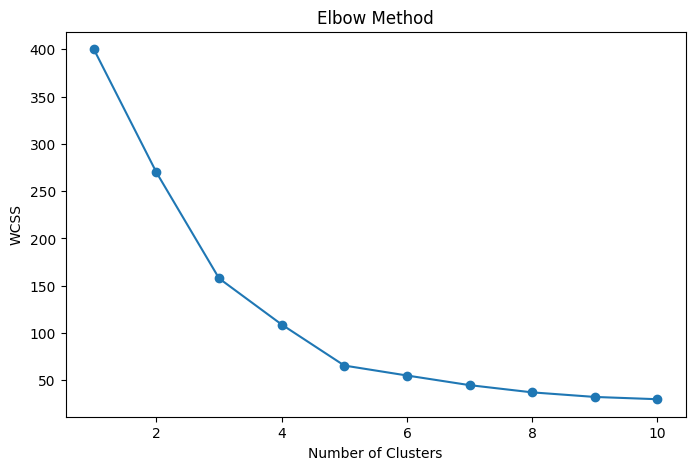

In [17]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')

plt.show()

Train K-Means

In [18]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

Number of Customers in Each Cluster

In [19]:
df['Cluster'].value_counts()

,count
Cluster,
0,81
1,39
3,35
4,23
2,22


Visualize Customer Segments

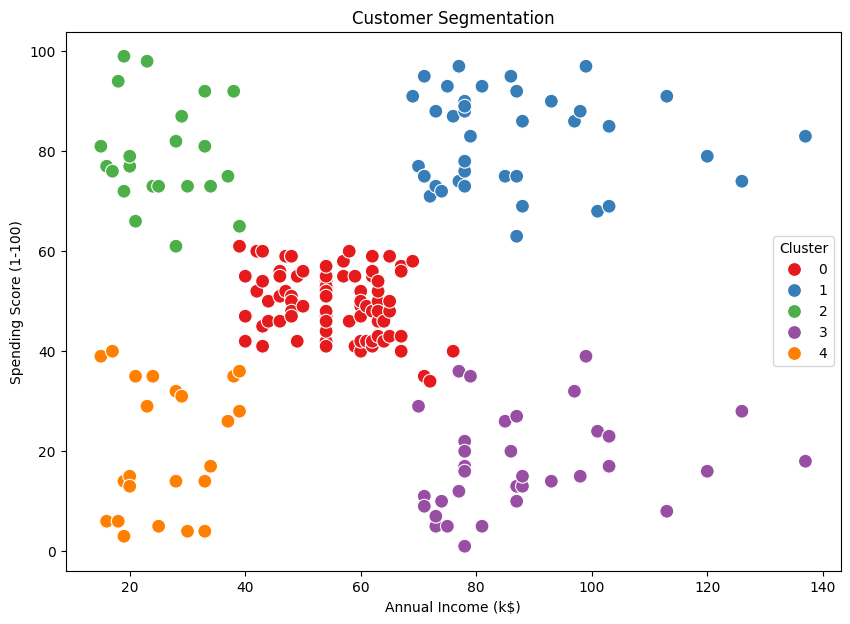

In [20]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    data=df,
    palette='Set1',
    s=100
)

plt.title('Customer Segmentation')
plt.show()

Silhouette Score

In [21]:
score = silhouette_score(
    X_scaled,
    clusters
)

print("Silhouette Score:", score)

Silhouette Score: 0.5546571631111091


PCA Visualization

In [22]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

pca_df['Cluster'] = clusters

PCA Visualization

In [23]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

pca_df['Cluster'] = clusters

Plot

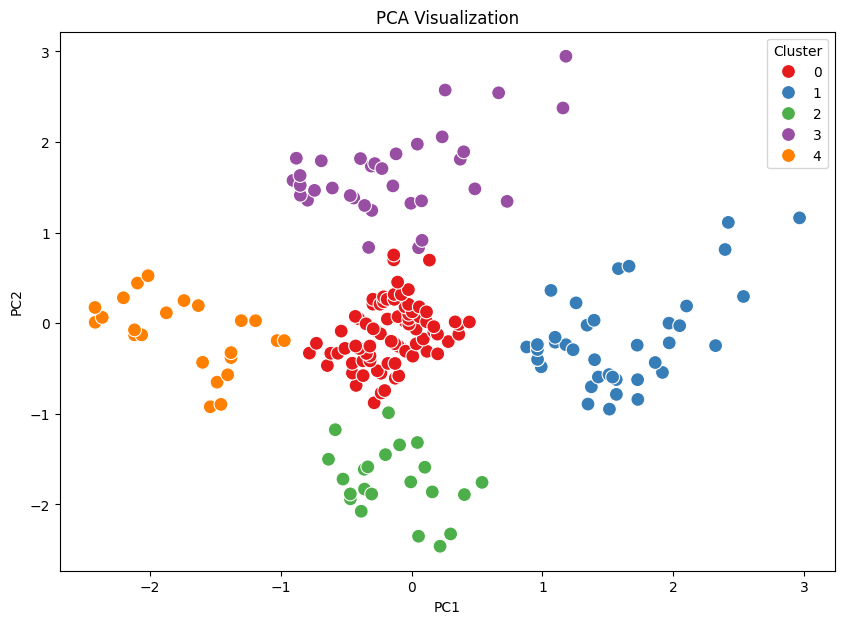

In [24]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    data=pca_df,
    palette='Set1',
    s=100
)

plt.title('PCA Visualization')
plt.show()

Analyze Clusters

In [25]:
df.groupby('Cluster')[[
    'Annual Income (k$)',
    'Spending Score (1-100)'
]].mean()

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


Using K-Means clustering, customers were divided into five distinct segments based on annual income and spending behavior. The analysis revealed groups of high-value customers, budget-conscious customers, and average spenders. These insights can help businesses design targeted marketing campaigns, loyalty programs, and promotional offers to improve customer engagement and increase revenue.